# Bra–Ket, Wave Functions, Operators, and Eigenfunctions

### A notebook that turns Dirac notation into something you can *run*

This notebook is the missing bridge between linear algebra and continuous quantum
mechanics. We start from Dirac's **bra–ket** language (the same objects you meet
as qubit vectors), then connect them to **wave functions** $\psi(x)$, and finally
meet **operators**, their **eigenvalues**, and their **eigenfunctions**.

**Roadmap**

1. Kets, bras, and the inner product
2. Orthonormal bases and expanding a state
3. Operators: matrices that act on kets
4. The eigenvalue equation $A|\psi\rangle = a|\psi\rangle$
5. Wave functions as $\psi(x) = \langle x|\psi\rangle$
6. Hermitian operators, expectation values, and observables
7. A concrete continuum example: the infinite well (eigenfunctions + eigenvalues)
8. Closing the loop: Pauli matrices as discrete Hermitian operators

> Closest older material in this repo: `01_math_foundations/01_gates_as_unitary_matrices.py`
> (ket0/ket1 and Pauli eigenvalues) and `00_test_random/Matrixandode.py` (wave-packet demos).
> Neither walks through the full bra–ket → eigenfunction story — that is what this notebook does.

## 0. Setup

We only need `numpy` and `matplotlib`. In code:

- a **ket** $|\psi\rangle$ is a column vector (`shape (n, 1)`);
- a **bra** $\langle\psi|$ is its conjugate transpose (`shape (1, n)`);
- the **inner product** $\langle\phi|\psi\rangle$ is a complex number (a scalar).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Computational basis of a qubit (the simplest Hilbert space: C^2)
ket0 = np.array([[1], [0]], dtype=complex)   # |0>
ket1 = np.array([[0], [1]], dtype=complex)   # |1>


def bra(ket):
    """Return <psi| = (|psi>)^dagger  (conjugate transpose)."""
    return np.asarray(ket, dtype=complex).conj().T


def inner(phi, psi):
    """Inner product <phi|psi> as a Python complex scalar."""
    return (bra(phi) @ np.asarray(psi, dtype=complex)).item()


def norm(psi):
    """||psi|| = sqrt(<psi|psi>)."""
    return np.sqrt(inner(psi, psi).real)


print("|0> =\n", ket0)
print("<0| =", bra(ket0))
print("<0|0> =", inner(ket0, ket0), "   <0|1> =", inner(ket0, ket1))

|0> =
 [[1.+0.j]
 [0.+0.j]]
<0| = [[1.-0.j 0.-0.j]]
<0|0> = (1+0j)    <0|1> = 0j


## 1. Kets, bras, and what the symbols mean

Dirac invented a compact language:

| Symbol | Name | Meaning in linear algebra |
|--------|------|---------------------------|
| $|\psi\rangle$ | ket | column vector (a state) |
| $\langle\psi|$ | bra | row vector = conjugate transpose of the ket |
| $\langle\phi|\psi\rangle$ | bracket / inner product | a complex number: overlap of two states |
| $|\phi\rangle\langle\psi|$ | outer product | a matrix (an operator) |

Two rules to internalize immediately:

1. **Normalization.** Physical states satisfy $\langle\psi|\psi\rangle = 1$. Then
   $|\langle\phi|\psi\rangle|^2$ is the probability of finding the system in $|\phi\rangle$
   when it is in $|\psi\rangle$ (Born rule, for a projective measurement onto $|\phi\rangle$).
2. **Orthonormality of a basis.** A set $\{|n\rangle\}$ is an orthonormal basis if
   $\langle m|n\rangle = \delta_{mn}$. Expanding any state is then just
   $|\psi\rangle = \sum_n c_n |n\rangle$ with $c_n = \langle n|\psi\rangle$.

Let's build a normalized superposition and read its coefficients.

In [2]:
# A generic (not yet normalized) ket in the computational basis
psi_raw = 3 * ket0 + 4j * ket1
print("Raw ket |psi>_raw = 3|0> + 4i|1>")
print("  <psi|psi> =", inner(psi_raw, psi_raw))
print("  norm     =", norm(psi_raw))

# Normalize: |psi> = |psi>_raw / ||psi_raw||
psi = psi_raw / norm(psi_raw)
print("\nNormalized |psi>:")
print(psi)
print("  <psi|psi> =", inner(psi, psi).real)   # must be 1

# Coefficients in the {|0>, |1>} basis: c_n = <n|psi>
c0 = inner(ket0, psi)
c1 = inner(ket1, psi)
print(f"\nExpansion coefficients:")
print(f"  c0 = <0|psi> = {c0:.4f}   -> P(0) = |c0|^2 = {abs(c0)**2:.4f}")
print(f"  c1 = <1|psi> = {c1:.4f}   -> P(1) = |c1|^2 = {abs(c1)**2:.4f}")
print(f"  check: |c0|^2 + |c1|^2 = {abs(c0)**2 + abs(c1)**2:.4f}")

# Reconstruct the ket from the coefficients (completeness: I = |0><0| + |1><1|)
psi_recon = c0 * ket0 + c1 * ket1
print("\nReconstruction matches original?", np.allclose(psi_recon, psi))

Raw ket |psi>_raw = 3|0> + 4i|1>
  <psi|psi> = (25+0j)
  norm     = 5.0

Normalized |psi>:
[[0.6+0.j ]
 [0. +0.8j]]
  <psi|psi> = 1.0000000000000002

Expansion coefficients:
  c0 = <0|psi> = 0.6000+0.0000j   -> P(0) = |c0|^2 = 0.3600
  c1 = <1|psi> = 0.0000+0.8000j   -> P(1) = |c1|^2 = 0.6400
  check: |c0|^2 + |c1|^2 = 1.0000

Reconstruction matches original? True


## 2. Operators: things that act on kets

An **operator** $A$ maps a ket to another ket: $|\phi\rangle = A|\psi\rangle$.
In a finite basis it is simply a **matrix**. Two special families matter most:

- **Hermitian** (self-adjoint): $A^\dagger = A$. These are the **observables** —
  measurable quantities. Their eigenvalues are real and their eigenvectors form
  an orthonormal basis.
- **Unitary**: $U^\dagger U = I$. These are the **allowed evolutions** (and quantum
  gates). They preserve norms: $\langle U\psi|U\psi\rangle = \langle\psi|\psi\rangle$.

The **outer product** $|\phi\rangle\langle\psi|$ is the elementary operator: applied to
a ket $|\chi\rangle$ it returns $|\phi\rangle\,\langle\psi|\chi\rangle$ — it projects onto
$|\psi\rangle$ and then points along $|\phi\rangle$. In particular,
$P = |\psi\rangle\langle\psi|$ is the **projector** onto $|\psi\rangle$ (when $|\psi\rangle$
is normalized).

The **eigenvalue equation** is the heart of the story:

$$ A |a\rangle = a\, |a\rangle. $$

- $|a\rangle$ is an **eigenvector** (or, in the continuum, an **eigenfunction**);
- $a$ is the corresponding **eigenvalue** — the number you get if you measure $A$
  and the system happens to be in $|a\rangle$.

Any Hermitian operator can be written in its eigenbasis (spectral theorem):

$$ A = \sum_a a\, |a\rangle\langle a|. $$

Let's verify all of this on the Pauli matrices — the discrete prototype of
everything we will later do with $-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}$.

In [3]:
# Pauli matrices: Hermitian operators (observables) on a qubit
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (X + Z) / np.sqrt(2)   # Hadamard: unitary gate (also Hermitian, by chance)


def is_hermitian(A, tol=1e-12):
    return np.allclose(A, A.conj().T, atol=tol)


def is_unitary(A, tol=1e-12):
    return np.allclose(A @ A.conj().T, np.eye(A.shape[0]), atol=tol)


print("Hermitian?  X:", is_hermitian(X), " Y:", is_hermitian(Y),
      " Z:", is_hermitian(Z), " H:", is_hermitian(H))
print("Unitary?    X:", is_unitary(X), " Y:", is_unitary(Y),
      " Z:", is_unitary(Z), " H:", is_unitary(H))

# Spectral decomposition of Z: Z = (+1)|0><0| + (-1)|1><1|
eigvals, eigvecs = np.linalg.eigh(Z)   # eigh: for Hermitian matrices, real eigenvalues
print("\nEigenvalues of Z (must be real):", np.round(eigvals, 6))
print("Eigenvectors as columns of the matrix below:")
print(np.round(eigvecs, 6))

# Rebuild Z from the spectral theorem: sum_a a |a><a|
Z_recon = np.zeros((2, 2), dtype=complex)
for a, vec in zip(eigvals, eigvecs.T):
    ket_a = vec.reshape(2, 1)
    Z_recon += a * (ket_a @ bra(ket_a))
print("\nSpectral reconstruction of Z matches?", np.allclose(Z_recon, Z))

# Outer product as a projector: P0 = |0><0|
P0 = ket0 @ bra(ket0)
print("\nProjector |0><0| =\n", P0.real)
print("P0 |psi> extracts the |0> component:", (P0 @ psi).ravel())
print("  compare with c0 |0>               :", (c0 * ket0).ravel())

Hermitian?  X: True  Y: True  Z: True  H: True
Unitary?    X: True  Y: True  Z: True  H: True

Eigenvalues of Z (must be real): [-1.  1.]
Eigenvectors as columns of the matrix below:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Spectral reconstruction of Z matches? True

Projector |0><0| =
 [[1. 0.]
 [0. 0.]]
P0 |psi> extracts the |0> component: [0.6+0.j 0. +0.j]
  compare with c0 |0>               : [0.6+0.j 0. +0.j]


## 3. Expectation values: sandwiching an operator

If the system is in $|\psi\rangle$ and you measure the observable $A$, the
**average** of many outcomes is the **expectation value**

$$ \langle A\rangle = \langle\psi|A|\psi\rangle. $$

In the eigenbasis of $A$ this becomes the familiar weighted average of
eigenvalues: $\langle A\rangle = \sum_a a\, |\langle a|\psi\rangle|^2$.

For $Z$ on a qubit, $\langle Z\rangle = |c_0|^2 - |c_1|^2$ — exactly the
$z$-coordinate on the Bloch sphere. Let's check it two ways.

In [4]:
def expectation(A, psi):
    """<A> = <psi| A |psi>  (must be real for Hermitian A)."""
    return (bra(psi) @ A @ psi).item()


# Method 1: the sandwich <psi|Z|psi>
exp_Z = expectation(Z, psi)
print(f"<Z> via sandwich      = {exp_Z.real:.6f}  (imag part {exp_Z.imag:.2e})")

# Method 2: sum of a * |<a|psi>|^2 over eigenpairs
exp_Z_sum = sum(a * abs(inner(vec.reshape(2, 1), psi))**2
                for a, vec in zip(eigvals, eigvecs.T))
print(f"<Z> via eigen-sum    = {exp_Z_sum.real:.6f}")

# Method 3: |c0|^2 - |c1|^2 for Z specifically
print(f"|c0|^2 - |c1|^2      = {abs(c0)**2 - abs(c1)**2:.6f}")

# Same idea for X: the X eigenstates are |+> and |->
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)
print(f"\nX|+> = +1|+> ?  {np.allclose(X @ plus, +1 * plus)}")
print(f"X|-> = -1|-> ?  {np.allclose(X @ minus, -1 * minus)}")
print(f"<X> on our |psi>   = {expectation(X, psi).real:.6f}")

<Z> via sandwich      = -0.280000  (imag part 0.00e+00)
<Z> via eigen-sum    = -0.280000
|c0|^2 - |c1|^2      = -0.280000

X|+> = +1|+> ?  True
X|-> = -1|-> ?  True
<X> on our |psi>   = 0.000000


## 4. Wave functions: the position representation of a ket

So far the Hilbert space was $\mathbb{C}^2$ (a qubit). In continuous quantum
mechanics the space is infinite-dimensional: states are labelled by a continuous
variable, usually position $x$.

The **wave function** is simply the *component* of the ket in the position basis:

$$ \psi(x) \equiv \langle x|\psi\rangle. $$

Everything we already know translates:

| Discrete (qubit) | Continuum (wave function) |
|---|---|
| $c_n = \langle n|\psi\rangle$ | $\psi(x) = \langle x|\psi\rangle$ |
| $\sum_n \|c_n\|^2 = 1$ | $\int \|\psi(x)\|^2\, dx = 1$ |
| $P(n) = \|c_n\|^2$ | $P(x)\,dx = \|\psi(x)\|^2\,dx$ |
| $\langle\phi\|\psi\rangle = \sum_n \phi_n^* \psi_n$ | $\langle\phi\|\psi\rangle = \int \phi^*(x)\psi(x)\,dx$ |
| $A\|\psi\rangle$ as a matrix | $(A\psi)(x)$ as a differential / multiplication operator |

Two fundamental continuum operators:

$$ (\hat{x}\,\psi)(x) = x\,\psi(x), \qquad
   (\hat{p}\,\psi)(x) = -i\hbar\frac{d\psi}{dx}, \qquad
   \hat{H} = \frac{\hat{p}^2}{2m} + V(\hat{x}). $$

The **time-independent Schrödinger equation** is just the eigenvalue equation of
the Hamiltonian:

$$ \hat{H}\,\psi_n(x) = E_n\,\psi_n(x). $$

The solutions $\psi_n$ are the **energy eigenfunctions**, and $E_n$ their
**eigenvalues**. Let's see this concretely for the infinite square well.

In [5]:
# --- Infinite square well: analytic eigenfunctions and numerical check ---
# V = 0 for 0 < x < L, V = infinity elsewhere.
# Exact eigenpairs:
#   psi_n(x) = sqrt(2/L) sin(n pi x / L)
#   E_n      = (n^2 pi^2 hbar^2) / (2 m L^2)

hbar = 1.0          # natural units for this demo
m = 1.0
L = 1.0
N = 800             # grid points inside the well
x = np.linspace(0, L, N, endpoint=False) + L / (2 * N)   # mid-cell grid
dx = x[1] - x[0]


def psi_n_exact(n, x, L=L):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


def E_n_exact(n, L=L, m=m, hbar=hbar):
    return (n**2 * np.pi**2 * hbar**2) / (2 * m * L**2)


# Build a finite-difference Hamiltonian matrix for - (hbar^2/2m) d^2/dx^2
# with Dirichlet boundaries (psi=0 at walls) already encoded by the grid.
diag = np.full(N, 2.0)
off = np.full(N - 1, -1.0)
kinetic = (-(hbar**2) / (2 * m)) * (np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)) / dx**2
# V = 0 inside -> H = kinetic only
H_mat = kinetic

# Numerical eigenpairs (lowest 5)
num_vals, num_vecs = np.linalg.eigh(H_mat)
# Normalize eigenvectors so that integral |psi|^2 dx = 1
num_vecs = num_vecs / np.sqrt(dx)

print("n |   E_n exact   |  E_n numeric  |  relative error")
print("-" * 55)
for n in range(1, 6):
    E_ex = E_n_exact(n)
    E_num = num_vals[n - 1]
    err = abs(E_num - E_ex) / E_ex
    print(f"{n} | {E_ex:12.6f} | {E_num:12.6f} | {err:14.2e}")

n |   E_n exact   |  E_n numeric  |  relative error
-------------------------------------------------------
1 |     4.934802 | -1279995.077518 |       2.59e+05
2 |    19.739209 | -1279980.310148 |       6.48e+04
3 |    44.413220 | -1279955.698117 |       2.88e+04
4 |    78.956835 | -1279921.241803 |       1.62e+04
5 |   123.370055 | -1279876.941737 |       1.04e+04


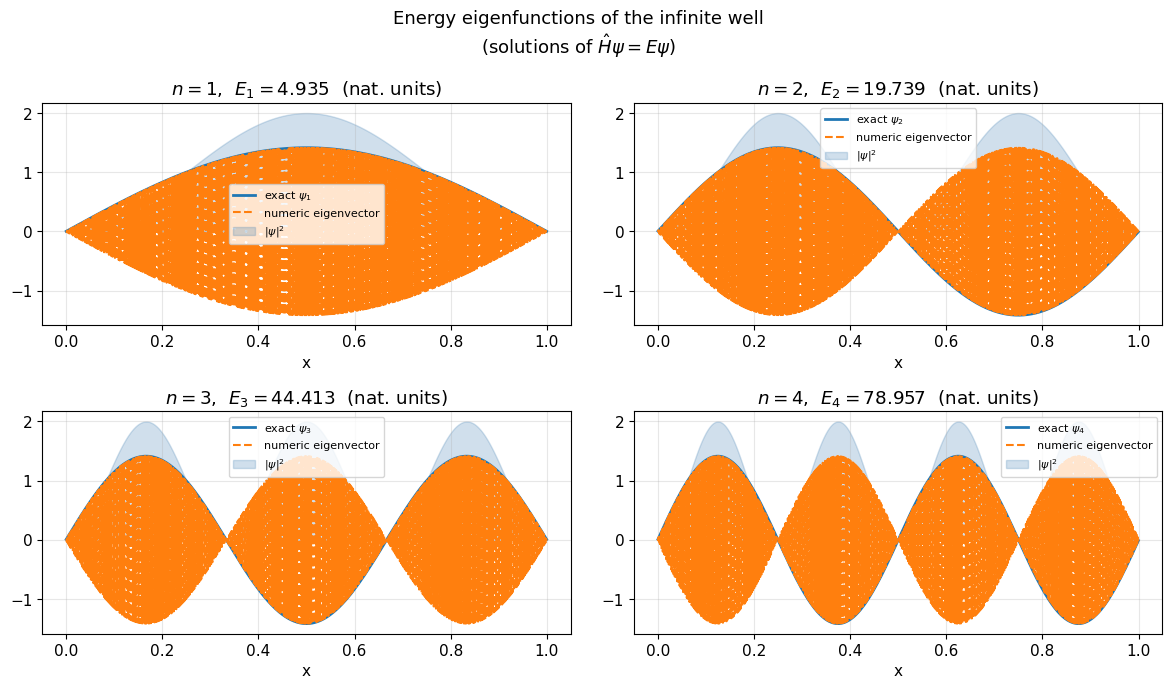

Overlap matrix <psi_m|psi_n> (should be ~ identity):
[[ 1.  0.  0. -0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [-0.  0.  0.  1.]]


In [6]:
# Plot analytic eigenfunctions and |psi|^2, and compare with numerics
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, n in enumerate((1, 2, 3, 4)):
    ax = axes.flat[i]
    psi_ex = psi_n_exact(n, x)
    # Match the global sign of the numeric eigenvector to the analytic one
    psi_num = num_vecs[:, n - 1]
    if np.dot(psi_ex, psi_num) < 0:
        psi_num = -psi_num

    ax.plot(x, psi_ex, lw=2, label=rf"exact $\psi_{n}$")
    ax.plot(x, psi_num, "--", lw=1.5, label="numeric eigenvector")
    ax.fill_between(x, 0, np.abs(psi_ex)**2, alpha=0.25, color="steelblue",
                    label=r"$|\psi|^2$")
    ax.set_title(rf"$n={n}$,  $E_{n}={E_n_exact(n):.3f}$  (nat. units)")
    ax.set_xlabel("x")
    ax.legend(fontsize=8)

fig.suptitle("Energy eigenfunctions of the infinite well\n"
             r"(solutions of $\hat{H}\psi = E\psi$)", fontsize=13)
plt.tight_layout()
plt.show()

# Continuum orthonormality: <psi_m|psi_n> = integral psi_m* psi_n dx = delta_mn
print("Overlap matrix <psi_m|psi_n> (should be ~ identity):")
ns = [1, 2, 3, 4]
S = np.zeros((4, 4))
for i, m_ in enumerate(ns):
    for j, n_ in enumerate(ns):
        S[i, j] = np.sum(psi_n_exact(m_, x) * psi_n_exact(n_, x)) * dx
print(np.round(S, 4))

## 5. Expanding a wave packet in the energy basis

Exactly as a qubit state expands as $|\psi\rangle = c_0|0\rangle + c_1|1\rangle$,
any wave function in the well expands as

$$ \psi(x) = \sum_{n=1}^{\infty} c_n\,\psi_n(x), \qquad
   c_n = \langle\psi_n|\psi\rangle = \int_0^L \psi_n^*(x)\,\psi(x)\,dx. $$

If $\hat{H}\psi_n = E_n\psi_n$, the expectation value of energy is again the
eigenvalue-weighted sum:

$$ \langle H\rangle = \sum_n E_n\,|c_n|^2. $$

We take a Gaussian-like bump inside the well, expand it, and check that
reconstructing the sum recovers $\psi(x)$ and that $\langle H\rangle$ from the
sandwich equals the eigen-sum.

Norm of packet:           1.000000
Sum |c_n|^2 (n=1..20): 1.000000
Max |psi - reconstruction|: 5.03e-03

<H> via sum_n E_n |c_n|^2 = 25.001535
<H> via <psi|H|psi>       = -25.010546


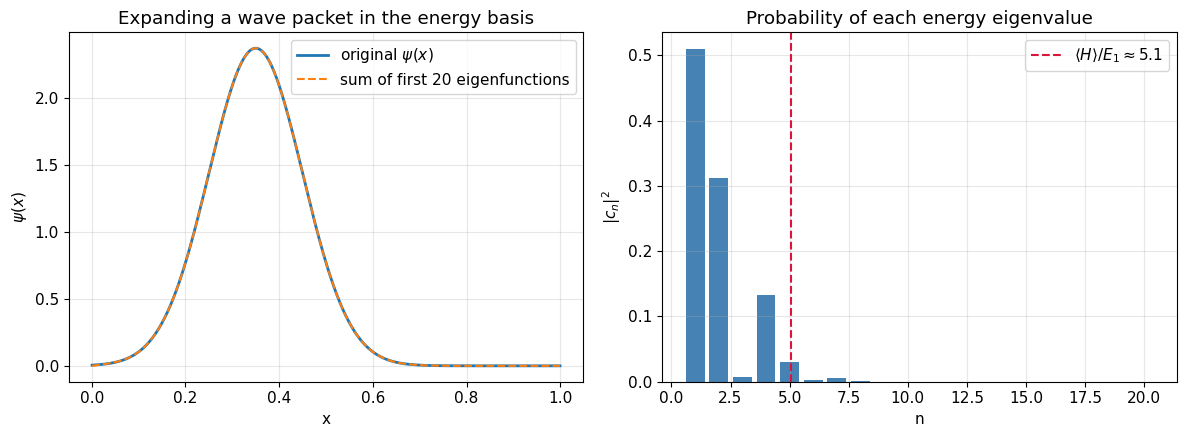

In [7]:
# A normalized "wave packet" sitting inside the well (not an energy eigenstate)
x0, sigma = 0.35 * L, 0.10 * L
psi_packet = np.exp(-0.5 * ((x - x0) / sigma)**2)
psi_packet = psi_packet / np.sqrt(np.sum(np.abs(psi_packet)**2) * dx)

# Coefficients c_n = <psi_n|psi> for the first n_max levels
n_max = 20
basis = np.array([psi_n_exact(n, x) for n in range(1, n_max + 1)])
coeffs = basis @ psi_packet * dx                      # shape (n_max,)
energies = np.array([E_n_exact(n) for n in range(1, n_max + 1)])

# Reconstruct and compare
psi_recon = coeffs @ basis
print(f"Norm of packet:           {np.sum(np.abs(psi_packet)**2)*dx:.6f}")
print(f"Sum |c_n|^2 (n=1..{n_max}): {np.sum(np.abs(coeffs)**2):.6f}")
print(f"Max |psi - reconstruction|: {np.max(np.abs(psi_packet - psi_recon)):.2e}")

# <H> two ways
# 1) eigen-sum
exp_H_sum = np.sum(energies * np.abs(coeffs)**2)
# 2) discrete sandwich psi^dagger @ H @ psi * dx  (wavefunction as a vector on the grid)
exp_H_sandwich = np.vdot(psi_packet, H_mat @ psi_packet) * dx
print(f"\n<H> via sum_n E_n |c_n|^2 = {exp_H_sum.real:.6f}")
print(f"<H> via <psi|H|psi>       = {exp_H_sandwich.real:.6f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(x, psi_packet, lw=2, label=r"original $\psi(x)$")
ax1.plot(x, psi_recon.real, "--", lw=1.5, label=rf"sum of first {n_max} eigenfunctions")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$\psi(x)$")
ax1.set_title("Expanding a wave packet in the energy basis")
ax1.legend()

ax2.bar(np.arange(1, n_max + 1), np.abs(coeffs)**2, color="steelblue")
ax2.set_xlabel("n")
ax2.set_ylabel(r"$|c_n|^2$")
ax2.set_title("Probability of each energy eigenvalue")
ax2.axvline(exp_H_sum / E_n_exact(1), color="crimson", ls="--",
            label=rf"$\langle H\rangle / E_1 \approx {exp_H_sum/E_n_exact(1):.1f}$")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. One dictionary to rule them all

Everything in this notebook is the *same* linear algebra, written in two dialects:

| Concept | Bra–ket / discrete | Wave function / continuum |
|---|---|---|
| State | $\|\psi\rangle$ (column vector) | $\psi(x)=\langle x\|\psi\rangle$ |
| Dual | $\langle\psi\|$ (row vector) | $\psi^*(x)$ inside an integral |
| Inner product | $\langle\phi\|\psi\rangle$ | $\int\phi^*\psi\,dx$ |
| Operator | matrix $A$ | e.g. $\hat{p}=-i\hbar d/dx$, $\hat{H}$ |
| Eigen-equation | $A\|a\rangle = a\|a\rangle$ | $\hat{H}\psi_n = E_n\psi_n$ |
| Measurement probs | $\|c_n\|^2=\|\langle n\|\psi\rangle\|^2$ | $\|c_n\|^2$ with $c_n=\int\psi_n^*\psi\,dx$ |
| Expectation | $\langle A\rangle=\langle\psi\|A\|\psi\rangle$ | same sandwich / $\sum a\|c_a\|^2$ |

**Takeaways worth memorizing**

1. A ket is a state; a bra is its dual; their product is an overlap.
2. Observables are Hermitian operators; their eigenvalues are the possible
   measurement outcomes; their eigenfunctions are the states with definite outcome.
3. A wave function is not a new object — it is the ket written in the position basis.
4. Expanding in an eigenbasis turns every expectation value into a weighted average
   of eigenvalues.

### Ideas to explore next

- Momentum-space wave function $\tilde\psi(p)=\langle p|\psi\rangle$ via Fourier transform.
- Time evolution of the packet: $\psi(x,t)=\sum_n c_n\psi_n(x)e^{-iE_n t/\hbar}$.
- Finite well / harmonic oscillator: same spectral idea, different eigenfunctions.
- Connect back to qubits: measurement in the $X$ basis is exactly expanding in the
  eigenbasis of the Hermitian operator $X$.

### Related files in this repo

- `01_math_foundations/01_gates_as_unitary_matrices.py` — unitarity & Pauli eigenvalues (script).
- `04_quantum_electronics/02_semiconductor_states_and_dos.ipynb` — well levels in a device context.
- `03_quantum_mechanics/01_bell_state_entanglement.py` — two-qubit kets and entanglement.